# Diabetes — Classical ML Baselines

A reproducible baseline experiment following the shared 25-section assignment workflow.

## 01. Problem Definition

Predict whether a respondent has diabetes (binary classification) and compare three classical ML model families.

## 02. Import Libraries

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix)

## 03. Experiment Configuration

In [2]:
EXPERIMENT_NAME = "ml_baseline"
TARGET = "Diabetes_binary"
SELECTED_FEATURES = ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
BEST_METRIC = "F1"

## 04. Paths

In [3]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data" / "diabetes.csv").exists():
    PROJECT_DIR = Path("project/diabetes")
DATA_DIR = PROJECT_DIR / "data"
FIGURE_DIR = PROJECT_DIR / "figures"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
for directory in (FIGURE_DIR, MODEL_DIR, OUTPUT_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print("Project directory:", PROJECT_DIR.resolve())

Project directory: D:\Nam_4\ki_1\HTTM\Assign_03\project\diabetes


## 05. Load Dataset

In [4]:
df = pd.read_csv(DATA_DIR / "diabetes.csv")
print("Shape:", df.shape)
display(df.head())

Shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## 06. Data Understanding

In [5]:
df.info()
display(df.describe().T)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
display(df[TARGET].value_counts().rename_axis("class").to_frame("count"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


Missing values: 0
Duplicate rows: 1635


,count
class,
0.0,35346
1.0,35346


## 07. Data Cleaning

Zeros are valid for the binary health indicators in this BRFSS dataset. Missing-value handling remains inside each pipeline to prevent leakage.

In [6]:
df = df.drop_duplicates().copy()
assert TARGET in df and set(SELECTED_FEATURES).issubset(df.columns)

## 08. Feature Engineering

The supplied BRFSS columns are already encoded numeric/ordinal features; no target-derived features are created.

## 09. Feature Selection

In [7]:
X = df[SELECTED_FEATURES].copy()
y = df[TARGET].astype(int)
print("Selected features ({}):".format(X.shape[1]), SELECTED_FEATURES)
display(y.value_counts(normalize=True).rename("proportion"))

Selected features (21): ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


Diabetes_binary
1    0.508232
0    0.491768
Name: proportion, dtype: float64

## 10. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (55245, 21) Test: (13812, 21)


## 11. Preprocessing

In [9]:
scaled_prep = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
tree_prep = Pipeline([("imputer", SimpleImputer(strategy="median"))])

## 12. Define 3 ML Models

In [10]:
models = {
    "Logistic Regression": Pipeline([("prep", scaled_prep), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "Decision Tree": Pipeline([("prep", tree_prep), ("model", DecisionTreeClassifier(max_depth=12, min_samples_leaf=10, random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("prep", tree_prep), ("model", RandomForestClassifier(n_estimators=150, min_samples_leaf=3, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE))]),
}
model_files = {"Logistic Regression": "logistic_regression.joblib", "Decision Tree": "decision_tree.joblib", "Random Forest": "random_forest.joblib"}

## 13. Train Models

In [11]:
predictions, probabilities = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]
    print("Trained:", name)

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest


## 14. Evaluation Metrics

In [12]:
rows = []
for name in models:
    pred, prob = predictions[name], probabilities[name]
    rows.append({"Model": name, "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred, zero_division=0),
                 "Recall": recall_score(y_test, pred, zero_division=0),
                 "F1": f1_score(y_test, pred, zero_division=0),
                 "ROC-AUC": roc_auc_score(y_test, prob)})

## 15. Model Comparison Table

In [13]:
results = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
display(results.style.format({c: "{:.4f}" for c in results.columns if c != "Model"}))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.7428,0.7287,0.7869,0.7567,0.8175
1,Logistic Regression,0.7449,0.7377,0.7729,0.7549,0.8174
2,Decision Tree,0.7187,0.7074,0.7615,0.7335,0.7873


## 16. Visualization

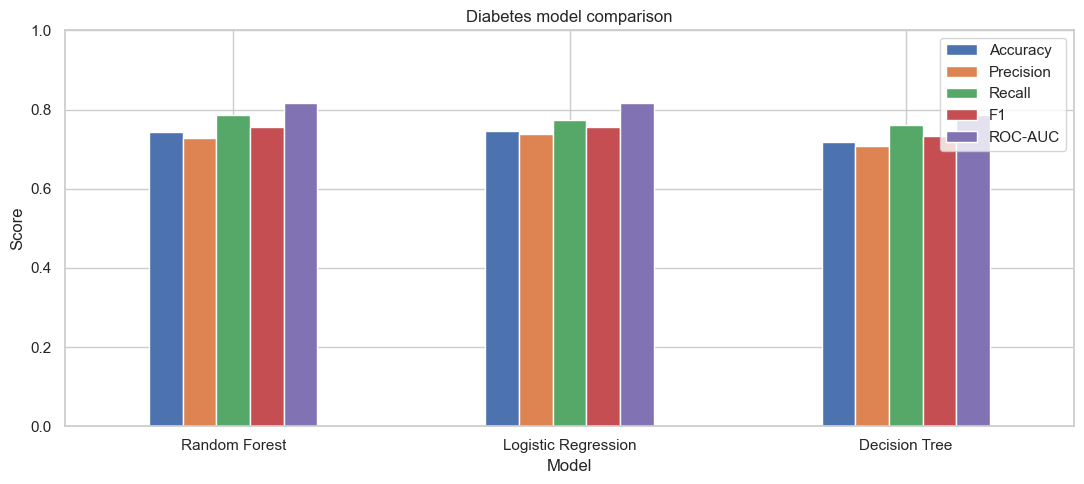

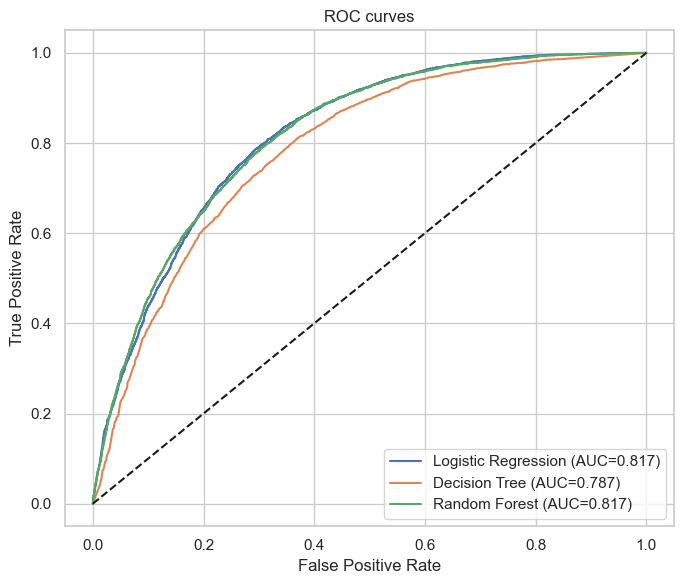

In [14]:
ax = results.set_index("Model").plot(kind="bar", figsize=(11, 5), ylim=(0, 1), rot=0)
ax.set_title("Diabetes model comparison"); ax.set_ylabel("Score"); plt.tight_layout()
plt.savefig(FIGURE_DIR / "ml_model_comparison.png", dpi=160); plt.show()

plt.figure(figsize=(7, 6))
for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
plt.plot([0, 1], [0, 1], "k--"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curves"); plt.legend(); plt.tight_layout()
plt.savefig(FIGURE_DIR / "ml_roc_curve.png", dpi=160); plt.show()

## 17. Select Best Model

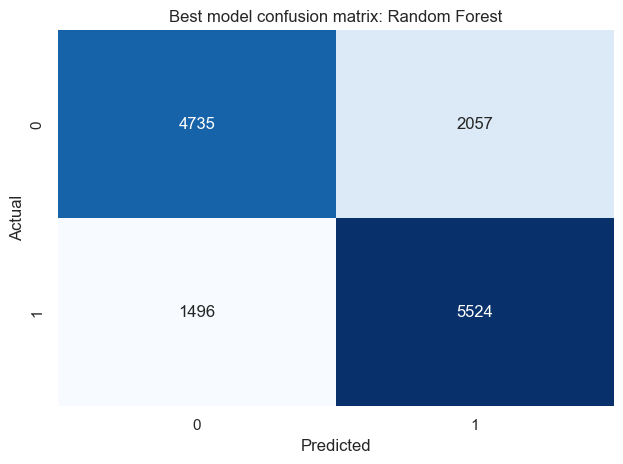

Best model by F1: Random Forest


In [15]:
best_name = results.iloc[0]["Model"]
best_model = models[best_name]
cm = confusion_matrix(y_test, predictions[best_name])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Best model confusion matrix: {best_name}"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout()
plt.savefig(FIGURE_DIR / "ml_best_confusion_matrix.png", dpi=160); plt.show()
print("Best model by F1:", best_name)

## 18. Save 3 Models

In [16]:
model_paths = {}
for name, model in models.items():
    path = MODEL_DIR / model_files[name]
    joblib.dump(model, path); model_paths[name] = path

## 19. Save Best Model

In [17]:
best_path = MODEL_DIR / "best_diabetes_model.joblib"
joblib.dump(best_model, best_path)
print(best_path)

D:\Nam_4\ki_1\HTTM\Assign_03\project\diabetes\models\best_diabetes_model.joblib


## 20. Save Results

In [18]:
results.to_csv(OUTPUT_DIR / "diabetes_ml_results.csv", index=False)

## 21. Save Feature/Config

In [19]:
config = {"experiment": EXPERIMENT_NAME, "task": "binary_classification", "target": TARGET,
          "features": SELECTED_FEATURES, "models": list(models), "best_metric": BEST_METRIC,
          "best_model": best_name, "random_state": RANDOM_STATE}
with open(OUTPUT_DIR / "model_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

## 22. Reload 3 Models

In [20]:
loaded_models = {name: joblib.load(path) for name, path in model_paths.items()}

## 23. Predict Test Sample

In [21]:
sample = X_test.iloc[[0]]; actual = int(y_test.iloc[0])
verification = pd.DataFrame([{"Model": name, "Prediction": int(model.predict(sample)[0]), "Actual": actual}
                             for name, model in loaded_models.items()])
display(verification)

,Model,Prediction,Actual
0,Logistic Regression,0,0
1,Decision Tree,0,0
2,Random Forest,0,0


## 24. Verify Saved Models

In [22]:
for name in models:
    np.testing.assert_array_equal(loaded_models[name].predict(sample), models[name].predict(sample))
assert joblib.load(best_path).predict(sample).shape == (1,)
print("[OK] All saved models loaded and predicted successfully.")

[OK] All saved models loaded and predicted successfully.


## 25. Conclusion

In [23]:
print(f"Best model: {best_name} | F1={results.iloc[0]['F1']:.4f} | ROC-AUC={results.iloc[0]['ROC-AUC']:.4f}")
print("All metrics, plots, configuration, and deployable pipelines were saved inside the diabetes folder.")

Best model: Random Forest | F1=0.7567 | ROC-AUC=0.8175
All metrics, plots, configuration, and deployable pipelines were saved inside the diabetes folder.
